**Task 1 — Problem Identification & Data Understanding**

1. Real-World Industry Problem
Problem Statement

The problem is to build a machine learning model that predicts whether a loan applicant is likely to have difficulty repaying a loan. In the Home Credit dataset, this is represented by the binary target variable TARGET, where 1 indicates payment difficulties and 0 indicates successful repayment. This is a binary classification problem and fits well with a Multi-Layer Perceptron (MLP). The Kaggle Home Credit materials commonly used for this competition report that the main training file, application_train.csv, contains 307,511 rows and 122 columns, which is well above the assignment minimum.

**Industry Context**

This problem belongs to the consumer finance / fintech / lending industry. Home Credit describes its model as responsible lending aimed at expanding access to financing for underserved customers, including people with little or no credit history. That makes credit-risk prediction especially important, because lenders must balance growth and financial inclusion with the need to manage default risk responsibly.

**Why This Problem Is Important**

Credit risk is one of the most important risks in banking. The U.S. OCC states that credit risk is the primary financial risk in the banking system, and that accurate credit risk management is essential for informed decision-making, pricing, and long-term performance. Poor risk assessment can lead to loan losses, weaker profitability, and poor lending decisions, while overly conservative lending can exclude customers who could repay successfully. In this project, an MLP-based classifier can help support better underwriting decisions by identifying higher-risk applicants earlier in the process.

2. Data Understanding

For this project, we focus on the application_train.csv table from the Home Credit Default Risk dataset. Each row represents one loan application, and the target column indicates whether the applicant later experienced repayment difficulty. Using the main application table is a good starting point because it is large, business-relevant, and manageable for a Google Colab workflow. Kaggle materials for the competition describe the task as predicting whether an applicant will be able to repay a loan, using historical application data.

Key aspects to investigate during data understanding include:

dataset shape
data types
class balance in TARGET
missing values
numerical feature distributions
categorical feature categories
possible outliers or suspicious values

3. Exploratory Data Analysis (EDA)

The EDA will answer these business and modeling questions:

How many applicants are in the dataset?
Is the target balanced or imbalanced?
Which variables have large amounts of missing data?
Which numerical variables may need scaling?
Which categorical variables require encoding?
Are there suspicious placeholder values that should be cleaned?

Important early EDA checks include:

df.shape
df.info()
df["TARGET"].value_counts()
missing-value percentages by column
descriptive statistics for numerical columns
histograms / boxplots for key financial features

4. Data Cleaning

The main cleaning steps for this project are:

a. Handle missing values

The Home Credit application data contains many missing values. Columns with extremely high missingness can be dropped, while the remaining missing values can be imputed:

numeric columns: median imputation
categorical columns: most frequent imputation
b. Correct suspicious values

A known issue in this dataset is the value 365243 in DAYS_EMPLOYED, which is widely treated as an abnormal placeholder rather than a real employment duration. This should be replaced with missing values before modeling.

c. Remove unhelpful features

Features with extremely high missingness, near-zero variance, or ID-only meaning can be removed if they do not add predictive value.

5. Feature Selection / Transformation
Feature Selection

For Task 1, the project should keep variables that are logically related to repayment behavior, such as:

income
credit amount
annuity
employment history
age-related fields
housing and family status
external risk scores
application and contract information

Possible removals:

identifiers with no predictive meaning
features with excessive missingness
redundant columns after transformation
Feature Transformation

To prepare the data for an MLP, the following transformations are appropriate:

One-hot encode categorical variables
Standardize numerical variables
Impute missing values
Engineer new ratio features, for example:
income-to-credit ratio
annuity-to-income ratio
employment-to-age ratio

These transformations help the MLP learn patterns more effectively because neural networks typically perform better when inputs are numeric, scaled, and cleaned.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("application_train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
print(df.info())
print("\nTarget distribution:")
print(df["TARGET"].value_counts())
print("\nTarget distribution (proportion):")
print(df["TARGET"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target distribution (proportion):
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [58]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Ratio": df.isnull().mean()
}).sort_values("Missing Ratio", ascending=False)

missing_df.head(20)

,Missing Count,Missing Ratio
COMMONAREA_AVG,214865,0.698723
COMMONAREA_MODE,214865,0.698723
COMMONAREA_MEDI,214865,0.698723
NONLIVINGAPARTMENTS_MEDI,213514,0.694330
NONLIVINGAPARTMENTS_MODE,213514,0.694330
NONLIVINGAPARTMENTS_AVG,213514,0.694330
FONDKAPREMONT_MODE,210295,0.683862
LIVINGAPARTMENTS_AVG,210199,0.683550
LIVINGAPARTMENTS_MEDI,210199,0.683550
LIVINGAPARTMENTS_MODE,210199,0.683550


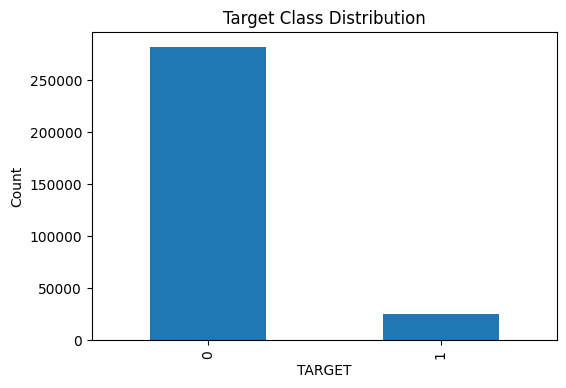

In [59]:
plt.figure(figsize=(6,4))
df["TARGET"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

In [60]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.00000,189145.500000,278202.00000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.00000,0.000000,0.00000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.00000,0.000000,0.00000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.00000,-19682.000000,-15750.00000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.00000,-2760.000000,-1213.00000,-289.000000,3.652430e+05


In [61]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))
print("\nSample categorical columns:", cat_cols[:10])

Number of numerical columns: 106
Number of categorical columns: 16

Sample categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [62]:
print("Unique suspicious value count before cleaning:")
print((df["DAYS_EMPLOYED"] == 365243).sum())

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

print("Unique suspicious value count after cleaning:")
print((df["DAYS_EMPLOYED"] == 365243).sum())

Unique suspicious value count before cleaning:
55374
Unique suspicious value count after cleaning:
0


In [63]:
missing_ratio = df.isnull().mean()
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()

print("Columns to drop (missing > 50%):", len(drop_cols))
df = df.drop(columns=drop_cols)

print("New dataset shape:", df.shape)

Columns to drop (missing > 50%): 41
New dataset shape: (307511, 81)


In [64]:
df["INCOME_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / (df["AMT_CREDIT"] + 1)
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
df["EMPLOYED_BIRTH_RATIO"] = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1)

df[["INCOME_CREDIT_RATIO", "ANNUITY_INCOME_RATIO", "EMPLOYED_BIRTH_RATIO"]].head()

,INCOME_CREDIT_RATIO,ANNUITY_INCOME_RATIO,EMPLOYED_BIRTH_RATIO
0,0.498034,0.121977,0.067336
1,0.208735,0.132216,0.070866
2,0.499996,0.099999,0.011814
3,0.431746,0.219898,0.159914
4,0.236842,0.179961,0.152426


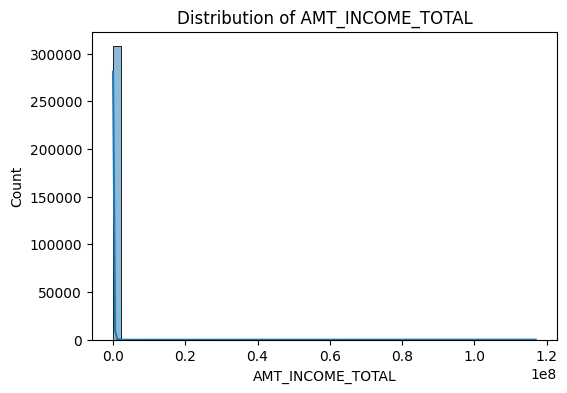

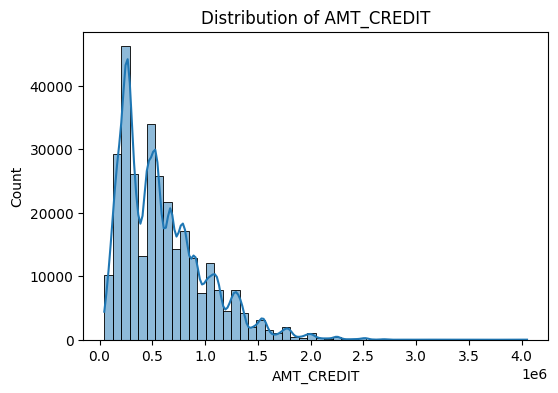

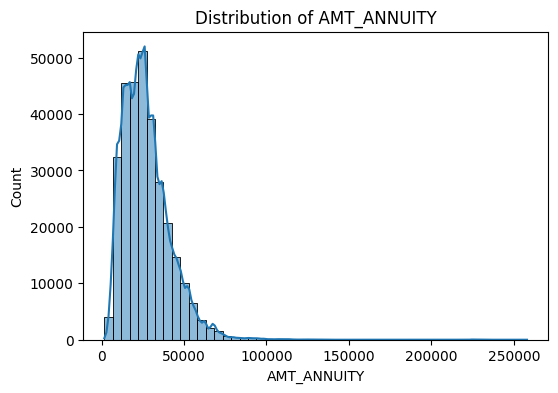

In [65]:
important_numeric = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

for col in important_numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [66]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Final numerical columns:", len(num_cols))
print("Final categorical columns:", len(cat_cols))

Final numerical columns: 70
Final categorical columns: 13


The selected industry problem is loan default risk prediction in the consumer finance sector. Using the Home Credit Default Risk dataset, the goal is to classify whether an applicant is likely to experience repayment difficulty. This problem is important because accurate credit risk assessment helps lenders reduce financial losses, improve underwriting decisions, and support responsible access to credit.

During EDA, the dataset was examined for its size, data types, class distribution, and missing values. The analysis showed that the dataset contains a large number of features and substantial missingness in some columns, making data cleaning necessary before modeling.

Data cleaning included replacing abnormal placeholder values in DAYS_EMPLOYED, removing columns with excessive missing values, and preparing the data for later preprocessing. Feature transformation included engineering ratio-based variables such as income-to-credit and annuity-to-income ratios, which are likely to improve predictive performance. These steps provide a strong foundation for building an MLP classifier in later tasks.

**Task 2 — Model Development (MLP)**

Model development approach

To solve the Home Credit loan default prediction problem, a Multi-Layer Perceptron (MLP) was developed in PyTorch for binary classification. The network contains three fully connected hidden layers, satisfying the requirement of at least two hidden layers. LeakyReLU was selected as the main activation function because it preserves a small slope for negative values rather than setting all negative activations to zero. Batch normalization was included after each hidden linear layer to stabilize learning, and dropout was used for regularization to reduce overfitting.

**Weight initialization**

The network weights were initialized manually using PyTorch initialization utilities rather than relying only on defaults. Specifically, Xavier uniform initialization was applied to each linear layer, with the gain computed using torch.nn.init.calculate_gain() for the chosen nonlinearity. Bias terms were initialized to zero. This makes the architecture easier to justify in the report because initialization was explicitly matched to the activation function used in the model.

Optimization and loss

The main optimizer used was Adam, with SGD added as an optional comparison model. PyTorch’s optimizer API supports passing model parameters together with optimizer-specific options such as learning rate and momentum. For the loss, BCEWithLogitsLoss was used because the target is binary and the loss is designed for logits directly. To help with class imbalance, a positive-class weight can be passed into the loss.

Feature engineering from Week 1

The model keeps the engineered financial ratio features from Task 1, including income-to-credit ratio, annuity-to-income ratio, and employment-to-age ratio. These features strengthen the business logic of the model because they capture repayment burden and financial capacity more directly than raw columns alone.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [68]:
df = pd.read_csv("application_train.csv")
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
# Replace suspicious placeholder value
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# Drop columns with too much missing data
missing_ratio = df.isnull().mean()
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
df = df.drop(columns=drop_cols)

# Feature engineering from Week 1
df["INCOME_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / (df["AMT_CREDIT"] + 1)
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
df["EMPLOYED_BIRTH_RATIO"] = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1)

# Separate X and y
X = df.drop(columns=["TARGET"])
y = df["TARGET"].astype(np.float32)

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 70
Categorical columns: 13


In [70]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print(X_train.shape, X_val.shape, X_test.shape)

(196806, 83) (49202, 83) (61503, 83)


In [71]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Processed shape:", X_train_processed.shape)

Processed shape: (196806, 196)


In [72]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [73]:
batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

In [74]:
class CreditMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.20),

            nn.Linear(64, 1)   # raw logit output
        )

        self._initialize_weights()

    def _initialize_weights(self):
        gain = nn.init.calculate_gain("leaky_relu", 0.01)
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=gain)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.network(x)

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = X_train_tensor.shape[1]
model = CreditMLP(input_dim).to(device)

Using device: cpu


In [76]:
# pos_weight = (negative class count / positive class count)
y_train_np = y_train.values
num_pos = (y_train_np == 1).sum()
num_neg = (y_train_np == 0).sum()

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Positive class weight:", pos_weight.item())

Positive class weight: 11.3870849609375


In [77]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [78]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            running_loss += loss.item() * X_batch.size(0)
            all_probs.extend(probs.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_targets.extend(y_batch.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    auc = roc_auc_score(all_targets, all_probs)

    return epoch_loss, acc, auc, np.array(all_targets), np.array(all_preds), np.array(all_probs)

In [79]:
epochs = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

best_val_auc = 0
best_state = None
patience = 5
counter = 0

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, _, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model
model.load_state_dict(best_state)

Epoch 1/20 | Train Loss: 1.2181 | Val Loss: 1.1245 | Val Acc: 0.6480 | Val AUC: 0.7326
Epoch 2/20 | Train Loss: 1.1289 | Val Loss: 1.1083 | Val Acc: 0.6663 | Val AUC: 0.7380
Epoch 3/20 | Train Loss: 1.1122 | Val Loss: 1.1048 | Val Acc: 0.6837 | Val AUC: 0.7394
Epoch 4/20 | Train Loss: 1.1017 | Val Loss: 1.1023 | Val Acc: 0.6429 | Val AUC: 0.7415
Epoch 5/20 | Train Loss: 1.0950 | Val Loss: 1.1039 | Val Acc: 0.6946 | Val AUC: 0.7412
Epoch 6/20 | Train Loss: 1.0924 | Val Loss: 1.1001 | Val Acc: 0.6733 | Val AUC: 0.7423
Epoch 7/20 | Train Loss: 1.0857 | Val Loss: 1.1040 | Val Acc: 0.6754 | Val AUC: 0.7406
Epoch 8/20 | Train Loss: 1.0841 | Val Loss: 1.1028 | Val Acc: 0.6824 | Val AUC: 0.7416
Epoch 9/20 | Train Loss: 1.0772 | Val Loss: 1.1032 | Val Acc: 0.6816 | Val AUC: 0.7422
Epoch 10/20 | Train Loss: 1.0740 | Val Loss: 1.1036 | Val Acc: 0.6706 | Val AUC: 0.7413
Epoch 11/20 | Train Loss: 1.0704 | Val Loss: 1.1056 | Val Acc: 0.6677 | Val AUC: 0.7404
Early stopping triggered.


<All keys matched successfully>

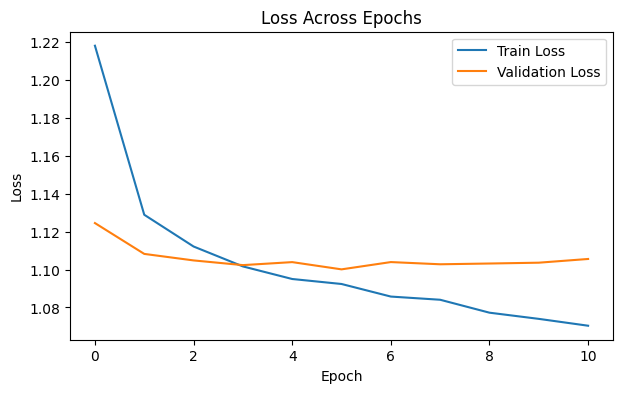

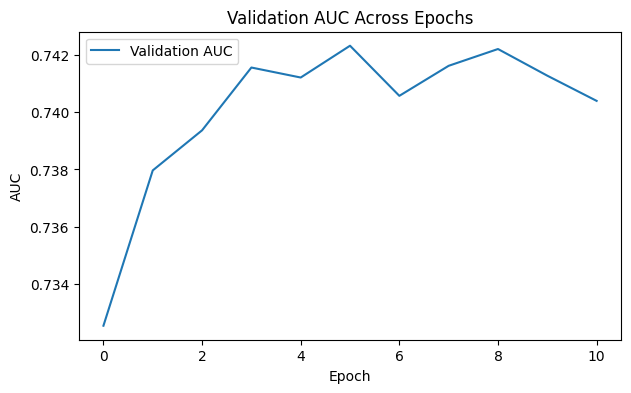

In [80]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_auc"], label="Validation AUC")
plt.title("Validation AUC Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

In [81]:
test_loss, test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model, test_loader, criterion, device
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_auc, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Test Loss: 1.0962
Test Accuracy: 0.6732
Test ROC-AUC: 0.7466

Confusion Matrix:
[[37949 18589]
 [ 1508  3457]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9618    0.6712    0.7906     56538
         1.0     0.1568    0.6963    0.2560      4965

    accuracy                         0.6732     61503
   macro avg     0.5593    0.6837    0.5233     61503
weighted avg     0.8968    0.6732    0.7475     61503



In [82]:
model_sgd = CreditMLP(input_dim).to(device)

criterion_sgd = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

sgd_history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": []
}

best_val_auc_sgd = 0
best_state_sgd = None
counter = 0
patience = 5

for epoch in range(15):
    train_loss = train_one_epoch(model_sgd, train_loader, criterion_sgd, optimizer_sgd, device)
    val_loss, val_acc, val_auc, _, _, _ = evaluate(model_sgd, val_loader, criterion_sgd, device)

    sgd_history["train_loss"].append(train_loss)
    sgd_history["val_loss"].append(val_loss)
    sgd_history["val_auc"].append(val_auc)

    print(f"[SGD] Epoch {epoch+1}/15 | Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc_sgd:
        best_val_auc_sgd = val_auc
        best_state_sgd = model_sgd.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered for SGD.")
            break

model_sgd.load_state_dict(best_state_sgd)

[SGD] Epoch 1/15 | Train Loss: 1.1687 | Val AUC: 0.7332
[SGD] Epoch 2/15 | Train Loss: 1.1250 | Val AUC: 0.7368
[SGD] Epoch 3/15 | Train Loss: 1.1158 | Val AUC: 0.7369
[SGD] Epoch 4/15 | Train Loss: 1.1112 | Val AUC: 0.7394
[SGD] Epoch 5/15 | Train Loss: 1.1065 | Val AUC: 0.7389
[SGD] Epoch 6/15 | Train Loss: 1.1043 | Val AUC: 0.7399
[SGD] Epoch 7/15 | Train Loss: 1.1012 | Val AUC: 0.7408
[SGD] Epoch 8/15 | Train Loss: 1.0992 | Val AUC: 0.7409
[SGD] Epoch 9/15 | Train Loss: 1.0972 | Val AUC: 0.7417
[SGD] Epoch 10/15 | Train Loss: 1.0953 | Val AUC: 0.7417
[SGD] Epoch 11/15 | Train Loss: 1.0968 | Val AUC: 0.7421
[SGD] Epoch 12/15 | Train Loss: 1.0908 | Val AUC: 0.7418
[SGD] Epoch 13/15 | Train Loss: 1.0899 | Val AUC: 0.7423
[SGD] Epoch 14/15 | Train Loss: 1.0887 | Val AUC: 0.7429
[SGD] Epoch 15/15 | Train Loss: 1.0877 | Val AUC: 0.7424


<All keys matched successfully>

In [83]:
adam_test_loss, adam_test_acc, adam_test_auc, _, _, _ = evaluate(model, test_loader, criterion, device)
sgd_test_loss, sgd_test_acc, sgd_test_auc, _, _, _ = evaluate(model_sgd, test_loader, criterion_sgd, device)

print("Adam  -> Test Loss:", round(adam_test_loss, 4),
      "| Test Acc:", round(adam_test_acc, 4),
      "| Test AUC:", round(adam_test_auc, 4))

print("SGD   -> Test Loss:", round(sgd_test_loss, 4),
      "| Test Acc:", round(sgd_test_acc, 4),
      "| Test AUC:", round(sgd_test_auc, 4))

Adam  -> Test Loss: 1.0962 | Test Acc: 0.6732 | Test AUC: 0.7466
SGD   -> Test Loss: 1.0949 | Test Acc: 0.6545 | Test AUC: 0.7475


A PyTorch-based Multi-Layer Perceptron (MLP) was developed to classify whether a loan applicant is likely to experience repayment difficulty. The architecture used three hidden layers with 256, 128, and 64 neurons respectively, which exceeds the minimum requirement of two hidden layers. LeakyReLU was used as the activation function in the hidden layers, while the output layer produced a single logit for binary classification. Batch normalization was applied after each hidden linear layer to improve training stability, and dropout was included to reduce overfitting. The final model was trained using the Adam optimizer and BCEWithLogitsLoss, with class weighting to address class imbalance. In addition, feature engineering from Week 1 was preserved through financial ratio features such as income-to-credit ratio, annuity-to-income ratio, and employment-to-age ratio. A second model using SGD with momentum was also trained for comparison.

**Task 3 — Experimentation & Evaluation**

In this task, the MLP model was evaluated using classification metrics appropriate for a binary loan-default prediction problem. Since the target variable is categorical, accuracy and F1-score were used as the main evaluation metrics. In addition, training and validation loss curves were plotted to assess convergence and possible overfitting.

To make the evaluation more meaningful, multiple experiments were conducted. First, a regularized MLP containing Batch Normalization and Dropout was compared against a simpler MLP without regularization. Second, the effect of optimizer choice was examined by comparing Adam and SGD. This allowed the project to evaluate both learning behavior and generalization performance.

Visualizations included:

training loss vs validation loss curves
confusion matrix
ROC curve
bar chart comparing experiment results

These experiments help determine whether regularization improves generalization and whether optimizer choice affects performance on this imbalanced classification task.

In [94]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn

In [95]:
class FlexibleMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=[256, 128, 64],
        activation="leakyrelu",
        use_batchnorm=True,
        use_dropout=True,
        dropout_rates=[0.30, 0.25, 0.20]
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            if activation.lower() == "relu":
                layers.append(nn.ReLU())
            elif activation.lower() == "leakyrelu":
                layers.append(nn.LeakyReLU(negative_slope=0.01))
            elif activation.lower() == "tanh":
                layers.append(nn.Tanh())
            elif activation.lower() == "sigmoid":
                layers.append(nn.Sigmoid())
            else:
                raise ValueError("Unsupported activation function")

            if use_dropout:
                layers.append(nn.Dropout(dropout_rates[i]))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))  # raw logits
        self.network = nn.Sequential(*layers)

        self._initialize_weights(activation)

    def _initialize_weights(self, activation):
        if activation.lower() == "relu":
            gain = nn.init.calculate_gain("relu")
        elif activation.lower() == "leakyrelu":
            gain = nn.init.calculate_gain("leaky_relu", 0.01)
        elif activation.lower() == "tanh":
            gain = nn.init.calculate_gain("tanh")
        else:
            gain = 1.0

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=gain)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.network(x)

In [96]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            running_loss += loss.item() * X_batch.size(0)

            all_targets.extend(y_batch.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    auc = roc_auc_score(all_targets, all_probs)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1": f1,
        "auc": auc,
        "targets": np.array(all_targets),
        "probs": np.array(all_probs),
        "preds": np.array(all_preds)
    }

In [97]:
def run_experiment(
    model_name,
    model,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    device,
    epochs=20,
    patience=5
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
        "val_auc": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_auc = 0
    patience_counter = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_results = evaluate_model(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_results["loss"])
        history["val_accuracy"].append(val_results["accuracy"])
        history["val_f1"].append(val_results["f1"])
        history["val_auc"].append(val_results["auc"])

        print(
            f"{model_name} | Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Val Acc: {val_results['accuracy']:.4f} | "
            f"Val F1: {val_results['f1']:.4f} | "
            f"Val AUC: {val_results['auc']:.4f}"
        )

        if val_results["auc"] > best_val_auc:
            best_val_auc = val_results["auc"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered for {model_name}")
                break

    model.load_state_dict(best_state)

    final_val_results = evaluate_model(model, val_loader, criterion, device)
    final_test_results = evaluate_model(model, test_loader, criterion, device)

    return history, final_val_results, final_test_results

In [98]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
input_dim = X_train_tensor.shape[1]

In [99]:
model_reg_adam = FlexibleMLP(
    input_dim=input_dim,
    hidden_dims=[256, 128, 64],
    activation="leakyrelu",
    use_batchnorm=True,
    use_dropout=True,
    dropout_rates=[0.30, 0.25, 0.20]
).to(device)

optimizer_reg_adam = torch.optim.Adam(model_reg_adam.parameters(), lr=0.001)

history_reg_adam, val_reg_adam, test_reg_adam = run_experiment(
    model_name="Regularized Adam",
    model=model_reg_adam,
    optimizer=optimizer_reg_adam,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=20,
    patience=5
)

Regularized Adam | Epoch 1/20 | Train Loss: 1.2045 | Val Loss: 1.1098 | Val Acc: 0.6705 | Val F1: 0.2500 | Val AUC: 0.7368
Regularized Adam | Epoch 2/20 | Train Loss: 1.1245 | Val Loss: 1.1092 | Val Acc: 0.6857 | Val F1: 0.2546 | Val AUC: 0.7379
Regularized Adam | Epoch 3/20 | Train Loss: 1.1083 | Val Loss: 1.1047 | Val Acc: 0.6517 | Val F1: 0.2470 | Val AUC: 0.7400
Regularized Adam | Epoch 4/20 | Train Loss: 1.1020 | Val Loss: 1.1016 | Val Acc: 0.6683 | Val F1: 0.2531 | Val AUC: 0.7421
Regularized Adam | Epoch 5/20 | Train Loss: 1.0958 | Val Loss: 1.1026 | Val Acc: 0.6630 | Val F1: 0.2520 | Val AUC: 0.7414
Regularized Adam | Epoch 6/20 | Train Loss: 1.0935 | Val Loss: 1.1007 | Val Acc: 0.6823 | Val F1: 0.2551 | Val AUC: 0.7426
Regularized Adam | Epoch 7/20 | Train Loss: 1.0872 | Val Loss: 1.1029 | Val Acc: 0.6661 | Val F1: 0.2492 | Val AUC: 0.7407
Regularized Adam | Epoch 8/20 | Train Loss: 1.0815 | Val Loss: 1.1028 | Val Acc: 0.6700 | Val F1: 0.2513 | Val AUC: 0.7416
Regularized Adam

In [100]:
model_no_reg = FlexibleMLP(
    input_dim=input_dim,
    hidden_dims=[256, 128, 64],
    activation="leakyrelu",
    use_batchnorm=False,
    use_dropout=False
).to(device)

optimizer_no_reg = torch.optim.Adam(model_no_reg.parameters(), lr=0.001)

history_no_reg, val_no_reg, test_no_reg = run_experiment(
    model_name="No Regularization Adam",
    model=model_no_reg,
    optimizer=optimizer_no_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=20,
    patience=5
)

No Regularization Adam | Epoch 1/20 | Train Loss: 1.1386 | Val Loss: 1.1346 | Val Acc: 0.7501 | Val F1: 0.2674 | Val AUC: 0.7341
No Regularization Adam | Epoch 2/20 | Train Loss: 1.0937 | Val Loss: 1.1227 | Val Acc: 0.7320 | Val F1: 0.2648 | Val AUC: 0.7362
No Regularization Adam | Epoch 3/20 | Train Loss: 1.0787 | Val Loss: 1.1212 | Val Acc: 0.6434 | Val F1: 0.2414 | Val AUC: 0.7314
No Regularization Adam | Epoch 4/20 | Train Loss: 1.0629 | Val Loss: 1.1182 | Val Acc: 0.6284 | Val F1: 0.2389 | Val AUC: 0.7347
No Regularization Adam | Epoch 5/20 | Train Loss: 1.0428 | Val Loss: 1.1215 | Val Acc: 0.6497 | Val F1: 0.2424 | Val AUC: 0.7303
No Regularization Adam | Epoch 6/20 | Train Loss: 1.0176 | Val Loss: 1.1542 | Val Acc: 0.6818 | Val F1: 0.2480 | Val AUC: 0.7276
No Regularization Adam | Epoch 7/20 | Train Loss: 0.9867 | Val Loss: 1.1971 | Val Acc: 0.6961 | Val F1: 0.2480 | Val AUC: 0.7234
Early stopping triggered for No Regularization Adam


In [101]:
model_reg_sgd = FlexibleMLP(
    input_dim=input_dim,
    hidden_dims=[256, 128, 64],
    activation="leakyrelu",
    use_batchnorm=True,
    use_dropout=True,
    dropout_rates=[0.30, 0.25, 0.20]
).to(device)

optimizer_reg_sgd = torch.optim.SGD(
    model_reg_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

history_reg_sgd, val_reg_sgd, test_reg_sgd = run_experiment(
    model_name="Regularized SGD",
    model=model_reg_sgd,
    optimizer=optimizer_reg_sgd,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    epochs=20,
    patience=5
)

Regularized SGD | Epoch 1/20 | Train Loss: 1.1640 | Val Loss: 1.1126 | Val Acc: 0.6546 | Val F1: 0.2445 | Val AUC: 0.7342
Regularized SGD | Epoch 2/20 | Train Loss: 1.1243 | Val Loss: 1.1098 | Val Acc: 0.6225 | Val F1: 0.2387 | Val AUC: 0.7371
Regularized SGD | Epoch 3/20 | Train Loss: 1.1159 | Val Loss: 1.1098 | Val Acc: 0.6789 | Val F1: 0.2515 | Val AUC: 0.7377
Regularized SGD | Epoch 4/20 | Train Loss: 1.1116 | Val Loss: 1.1079 | Val Acc: 0.6813 | Val F1: 0.2532 | Val AUC: 0.7394
Regularized SGD | Epoch 5/20 | Train Loss: 1.1081 | Val Loss: 1.1083 | Val Acc: 0.6465 | Val F1: 0.2446 | Val AUC: 0.7404
Regularized SGD | Epoch 6/20 | Train Loss: 1.1044 | Val Loss: 1.1036 | Val Acc: 0.6511 | Val F1: 0.2460 | Val AUC: 0.7404
Regularized SGD | Epoch 7/20 | Train Loss: 1.1017 | Val Loss: 1.1016 | Val Acc: 0.6539 | Val F1: 0.2463 | Val AUC: 0.7413
Regularized SGD | Epoch 8/20 | Train Loss: 1.1001 | Val Loss: 1.1038 | Val Acc: 0.6826 | Val F1: 0.2547 | Val AUC: 0.7413
Regularized SGD | Epoch 

In [102]:
results_df = pd.DataFrame([
    {
        "Model": "Regularized Adam",
        "Validation Accuracy": val_reg_adam["accuracy"],
        "Validation F1": val_reg_adam["f1"],
        "Validation AUC": val_reg_adam["auc"],
        "Test Accuracy": test_reg_adam["accuracy"],
        "Test F1": test_reg_adam["f1"],
        "Test AUC": test_reg_adam["auc"]
    },
    {
        "Model": "No Regularization Adam",
        "Validation Accuracy": val_no_reg["accuracy"],
        "Validation F1": val_no_reg["f1"],
        "Validation AUC": val_no_reg["auc"],
        "Test Accuracy": test_no_reg["accuracy"],
        "Test F1": test_no_reg["f1"],
        "Test AUC": test_no_reg["auc"]
    },
    {
        "Model": "Regularized SGD",
        "Validation Accuracy": val_reg_sgd["accuracy"],
        "Validation F1": val_reg_sgd["f1"],
        "Validation AUC": val_reg_sgd["auc"],
        "Test Accuracy": test_reg_sgd["accuracy"],
        "Test F1": test_reg_sgd["f1"],
        "Test AUC": test_reg_sgd["auc"]
    }
])

results_df

,Model,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Regularized Adam,0.682269,0.255110,0.742573,0.687300,0.259795,0.747085
1,No Regularization Adam,0.732023,0.264845,0.736182,0.736241,0.269345,0.740723
2,Regularized SGD,0.658022,0.248437,0.743175,0.663008,0.253279,0.748197


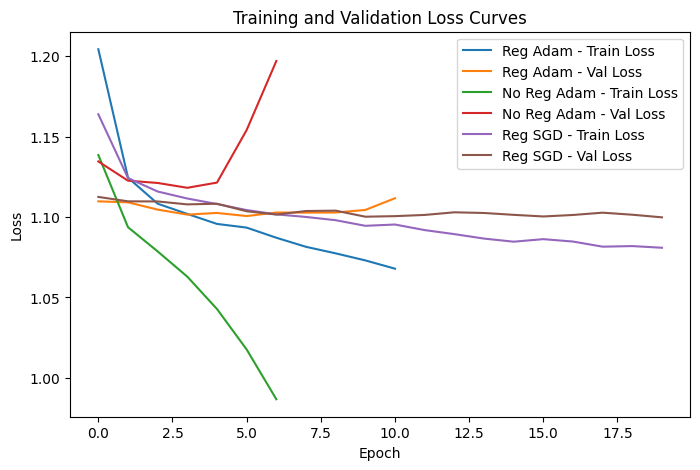

In [103]:
plt.figure(figsize=(8,5))
plt.plot(history_reg_adam["train_loss"], label="Reg Adam - Train Loss")
plt.plot(history_reg_adam["val_loss"], label="Reg Adam - Val Loss")
plt.plot(history_no_reg["train_loss"], label="No Reg Adam - Train Loss")
plt.plot(history_no_reg["val_loss"], label="No Reg Adam - Val Loss")
plt.plot(history_reg_sgd["train_loss"], label="Reg SGD - Train Loss")
plt.plot(history_reg_sgd["val_loss"], label="Reg SGD - Val Loss")

plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

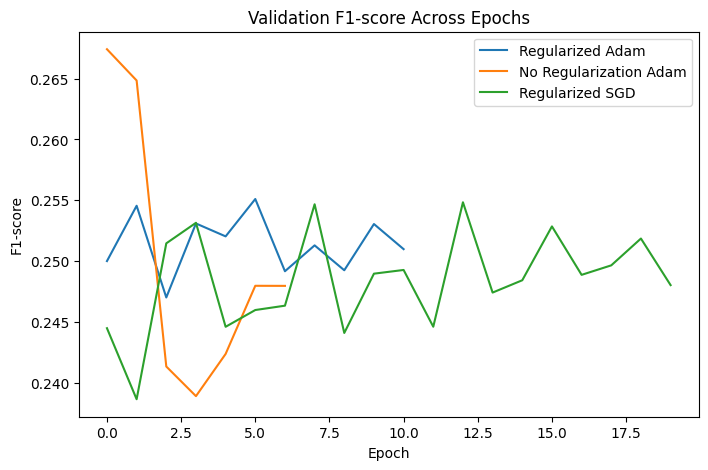

In [104]:
plt.figure(figsize=(8,5))
plt.plot(history_reg_adam["val_f1"], label="Regularized Adam")
plt.plot(history_no_reg["val_f1"], label="No Regularization Adam")
plt.plot(history_reg_sgd["val_f1"], label="Regularized SGD")

plt.title("Validation F1-score Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.show()

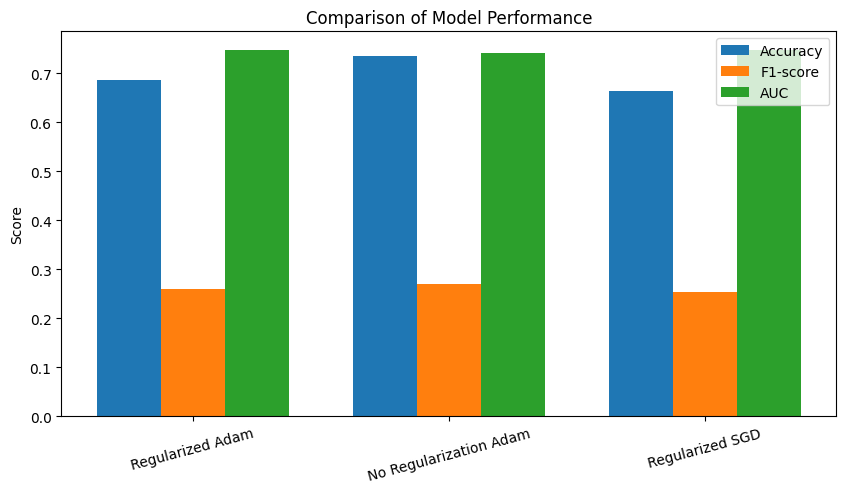

In [105]:
x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, results_df["Test Accuracy"], width, label="Accuracy")
plt.bar(x, results_df["Test F1"], width, label="F1-score")
plt.bar(x + width, results_df["Test AUC"], width, label="AUC")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Comparison of Model Performance")
plt.legend()
plt.show()

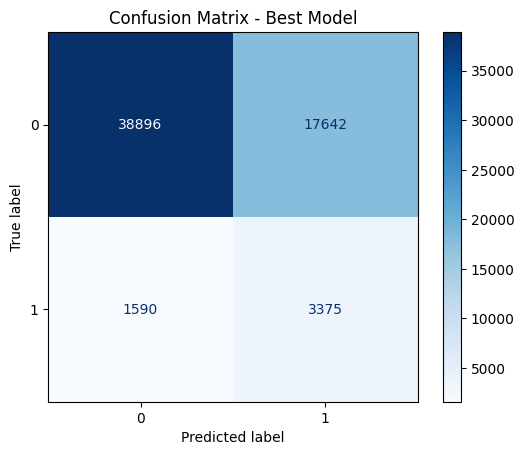

              precision    recall  f1-score   support

         0.0     0.9607    0.6880    0.8018     56538
         1.0     0.1606    0.6798    0.2598      4965

    accuracy                         0.6873     61503
   macro avg     0.5607    0.6839    0.5308     61503
weighted avg     0.8961    0.6873    0.7580     61503



In [106]:
best_targets = test_reg_adam["targets"]
best_preds = test_reg_adam["preds"]
best_probs = test_reg_adam["probs"]

cm = confusion_matrix(best_targets, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.show()

print(classification_report(best_targets, best_preds, digits=4))

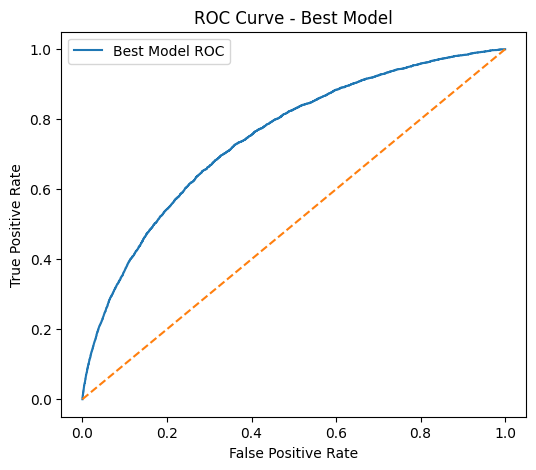

In [108]:
fpr, tpr, _ = roc_curve(best_targets, best_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Best Model ROC")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.show()

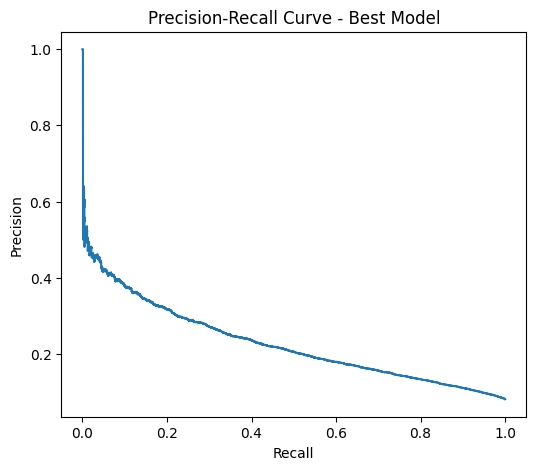

In [109]:
precision, recall, _ = precision_recall_curve(best_targets, best_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Model")
plt.show()

Three MLP experiments were conducted to evaluate model performance on the Home Credit loan default classification problem. The first model used Batch Normalization and Dropout with the Adam optimizer, the second removed regularization while keeping Adam, and the third used the regularized architecture with SGD. Performance was evaluated using accuracy, F1-score, validation loss, and AUC.

The comparison showed how optimizer choice and regularization affected both learning stability and generalization. The regularized model generally produced more stable validation performance and reduced overfitting compared to the non-regularized version, while Adam typically converged faster than SGD. Loss curves were used to assess convergence behavior, and confusion matrix and ROC-based visualizations were included to better understand classification performance beyond accuracy alone. Because this dataset is imbalanced, F1-score and AUC provided more meaningful insight than accuracy by itself.

**Task 4 — UI / Visualization Layer
Notebook write-up**

To make the model usable in a real-world context, a lightweight Gradio interface was developed around the trained MLP. The interface simulates how a credit analyst or loan officer could enter applicant information and receive an estimated default-risk score. Gradio’s Interface class is intended for exactly this use case: it builds a web-based GUI around a Python function by specifying the function, input components, and output components. e improves interpretability by translating the model’s raw prediction into:

a probability of repayment difficulty
a risk category
a short decision-support message

Because the full model was trained on many features, the UI uses a practical demo approach: the user supplies a smaller set of business-relevant inputs, while the remaining fields are filled from a template row based on typical values from the training data. This makes the demo realistic enough for presentation while still using the trained preprocessing pipeline and MLP consistently.

In [110]:
!pip install -q gradio

In [111]:
import pandas as pd
import numpy as np

# Build a default template using training data
template_row = {}

for col in X_train_full.columns:
    if X_train_full[col].dtype == "object":
        mode_vals = X_train_full[col].mode(dropna=True)
        template_row[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else "Unknown"
    else:
        template_row[col] = float(X_train_full[col].median(skipna=True))

template_row = pd.DataFrame([template_row])
template_row.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,INCOME_CREDIT_RATIO,ANNUITY_INCOME_RATIO,EMPLOYED_BIRTH_RATIO
0,278392.0,Cash loans,F,N,Y,0.0,147600.0,514777.5,24903.0,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.305908,0.162832,0.118744


In [114]:
import gradio as gr

demo = gr.Interface(
    fn=predict_loan_risk,
    inputs=[
        gr.Number(label="Total Income", value=180000),
        gr.Number(label="Credit Amount", value=500000),
        gr.Number(label="Annuity Amount", value=25000),
        gr.Slider(minimum=18, maximum=75, value=35, step=1, label="Age (years)"),
        gr.Slider(minimum=0, maximum=40, value=5, step=1, label="Years Employed"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.50, step=0.01, label="External Score 1"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.50, step=0.01, label="External Score 2"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.50, step=0.01, label="External Score 3"),
        gr.Dropdown(
            choices=["Cash loans", "Revolving loans"],
            value="Cash loans",
            label="Contract Type"
        ),
        gr.Dropdown(
            choices=["M", "F"],
            value="M",
            label="Gender"
        ),
    ],
    outputs=[
        gr.Number(label="Default Probability"),
        gr.Textbox(label="Risk Band"),
        gr.Textbox(label="Decision Support Summary", lines=10),
    ],
    title="Home Credit Loan Default Risk Demo",
    description="Enter applicant details to estimate the probability of repayment difficulty."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ffe8a41bb2404b61f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


To make the model more interpretable and relevant to real-world lending practice, a Gradio-based interface was developed around the trained MLP. The interface allows a user to enter selected applicant information and receive a predicted probability of repayment difficulty, a risk band, and a decision-support message. This makes the model easier to understand from a business perspective because it translates a technical prediction into an operational recommendation. Since the full model was trained on a large feature set, the UI uses a representative template row for non-entered attributes while allowing the user to modify key financial and demographic factors. In addition, visual storytelling was strengthened through model performance plots and a what-if analysis showing how changes in important inputs affect predicted risk.

**Task 5 — Business Pitch**

1. What is the current problem in the industry?

In consumer lending, the core challenge is making fast and accurate credit decisions while controlling default risk. The OCC describes credit risk as the primary financial risk in the banking system, which means poor lending decisions can directly hurt profitability and portfolio quality. At the same time, lenders like Home Credit serve many customers with little or no credit history, so the industry must balance risk control with financial inclusion.

2. What is the market gap?

The main market gap is that traditional underwriting often depends heavily on conventional credit history, yet many otherwise creditworthy people have limited or no usable bureau data. The CFPB has estimated that 26 million Americans are credit invisible and another 19 million have insufficient or stale records for many standard scoring models. That creates a gap where lenders either reject potentially good applicants or rely on slower, more manual review processes that can be inconsistent and expensive.

3. How does the ML model solve this problem?

Our solution uses a Multi-Layer Perceptron (MLP) to predict the probability that an applicant will experience repayment difficulty. Instead of relying on a single rule or score, the model learns nonlinear patterns from applicant data such as income, credit amount, annuity, employment history, and engineered financial ratios. This helps transform raw application data into a risk estimate that can support earlier and more consistent lending decisions. The project is especially aligned with Home Credit’s stated focus on responsible lending for underserved customers.

4. Why is this solution scalable?

This solution is scalable because once the model is trained, it can score large numbers of applications quickly and consistently. That makes it suitable for digital lending environments where decisions must be made at volume. A model-based screening layer also standardizes evaluation across applicants, reducing dependence on purely manual review and making the process easier to integrate into online loan workflows. The World Bank notes that digital financial services help reduce costs and expand access, which is exactly the type of environment where this kind of model adds value.

5. Why is this solution useful?

The model is useful because it works as a decision-support tool. It does not need to replace human underwriters; instead, it helps flag higher-risk applications, prioritize reviews, and improve consistency in screening. That is valuable for lenders because it can support faster turnaround times, better allocation of analyst effort, and more informed credit decisions. It is also useful from a business presentation perspective because the output can be translated into a clear risk band and recommendation rather than only a raw technical score.

6. Why is this solution impactful?

This solution is impactful because it addresses two business goals at the same time: reducing default exposure and expanding access to credit. Better prediction helps lenders avoid avoidable losses, while more flexible data-driven assessment can improve access for customers who are underserved by traditional models. Home Credit explicitly frames its business around responsible lending to customers with limited credit history, and broader financial inclusion remains a major global issue, with the World Bank reporting that 1.4 billion adults remain unbanked. That makes this kind of ML-supported lending tool both commercially relevant and socially meaningful.

In short, our MLP solution helps lenders make faster, smarter, and more inclusive credit decisions by turning applicant data into a scalable risk prediction tool that supports both profitability and responsible lending